# Ahmed Abdelsalam — CatBoost Model
## Paper: *Machine Learning Approach for Predicting SLE — Oman Medical Journal 2023*
---
## Section 1: EDA & Preprocessing

In [57]:
!pip install catboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay, recall_score, precision_score, f1_score
)
from catboost import CatBoostClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded.")

Libraries loaded.


In [58]:
file_path = '/content/TEAM22_Master_Dataset.csv'
df = pd.read_csv(file_path)
display(df.head())

,Patient_ID,MCHC,Anti_tissue_transglutaminase,MCV,Progesterone_antibodies,Eosinophils,Anti_desmoglein_1,Weight loss,Anti_parietal_cell,C3,...,Dizziness,ACPA,Anti_BP230,Brittle hair or hair loss,C1_inhibitor,Anti_CBir1,DGP,EMA,anti_Scl_70,Gender
0,1,33.12,0.0,99.85,0.0,4.02,0.0,0.0,0.0,1.32,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female
1,2,31.07,0.0,94.86,0.0,1.67,0.0,1.0,0.0,0.40,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Male
2,3,35.61,0.0,88.26,0.0,4.32,0.0,0.0,0.0,0.95,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male
3,4,33.93,0.0,85.95,0.0,3.12,0.0,1.0,0.0,1.06,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Female
4,5,31.29,0.0,93.16,0.0,4.60,0.0,1.0,0.0,0.73,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female


### Data Quality & Health Check

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45205 entries, 0 to 45204
Data columns (total 79 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            45205 non-null  int64  
 1   MCHC                                  45205 non-null  float64
 2   Anti_tissue_transglutaminase          45205 non-null  float64
 3   MCV                                   45205 non-null  float64
 4   Progesterone_antibodies               45205 non-null  float64
 5   Eosinophils                           45205 non-null  float64
 6   Anti_desmoglein_1                     45205 non-null  float64
 7   Weight loss                           45205 non-null  float64
 8   Anti_parietal_cell                    45205 non-null  float64
 9   C3                                    45205 non-null  float64
 10  Hematocrit                            45205 non-null  float64
 11  pANCA          

In [60]:
df.isnull().sum()

,0
Patient_ID,0
MCHC,0
Anti_tissue_transglutaminase,0
MCV,0
Progesterone_antibodies,0
...,...
Anti_CBir1,0
DGP,0
EMA,0
anti_Scl_70,0


In [61]:
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Shape after dropping duplicates: (45205, 79)


### Target Variable Analysis (Class Imbalance)

In [62]:
target_col = 'Diagnosis'
print("DISEASE DISTRIBUTION")
display(df[target_col].value_counts())

DISEASE DISTRIBUTION


,count
Diagnosis,
Normal,6960
Autoimmune orchitis,5142
Systemic lupus erythematosus (SLE),5016
Endometriosis,5000
Rheumatoid arthritis,4711
...,...
Sydenham's chorea,68
Rheumatic heart disease,67
Polyarteritis nodosa (PAN),63


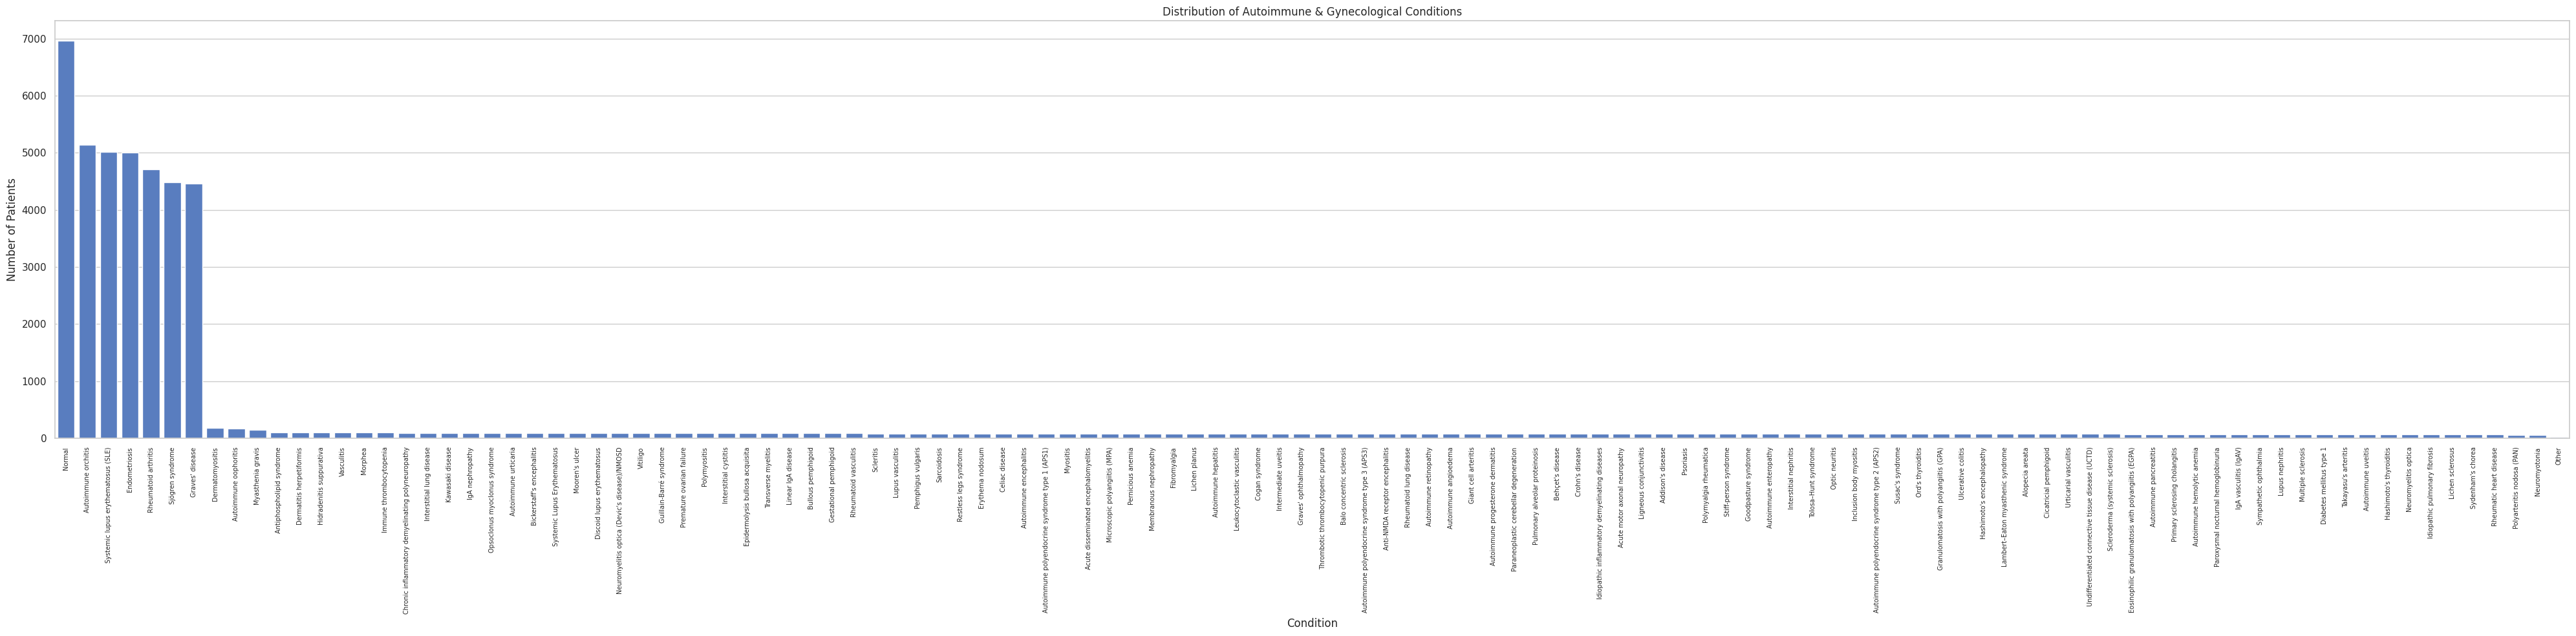

In [63]:
plt.figure(figsize=(40, 10))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title('Distribution of Autoimmune & Gynecological Conditions')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

### Univariate Analysis (Examining Clinical Features)

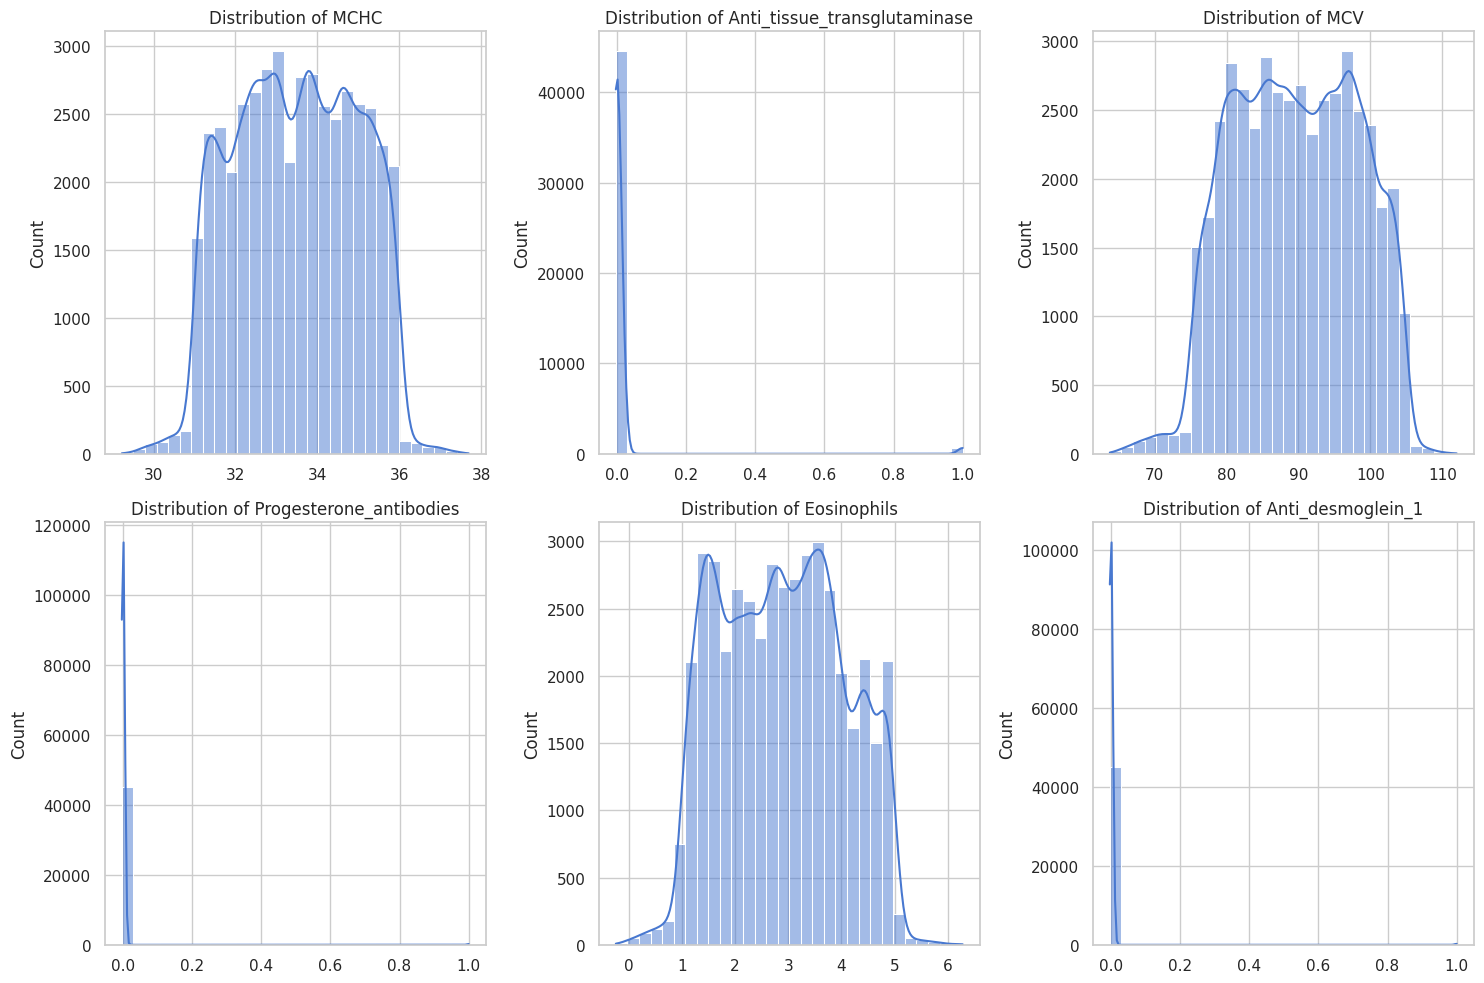

In [64]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('Patient_ID', errors='ignore')

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

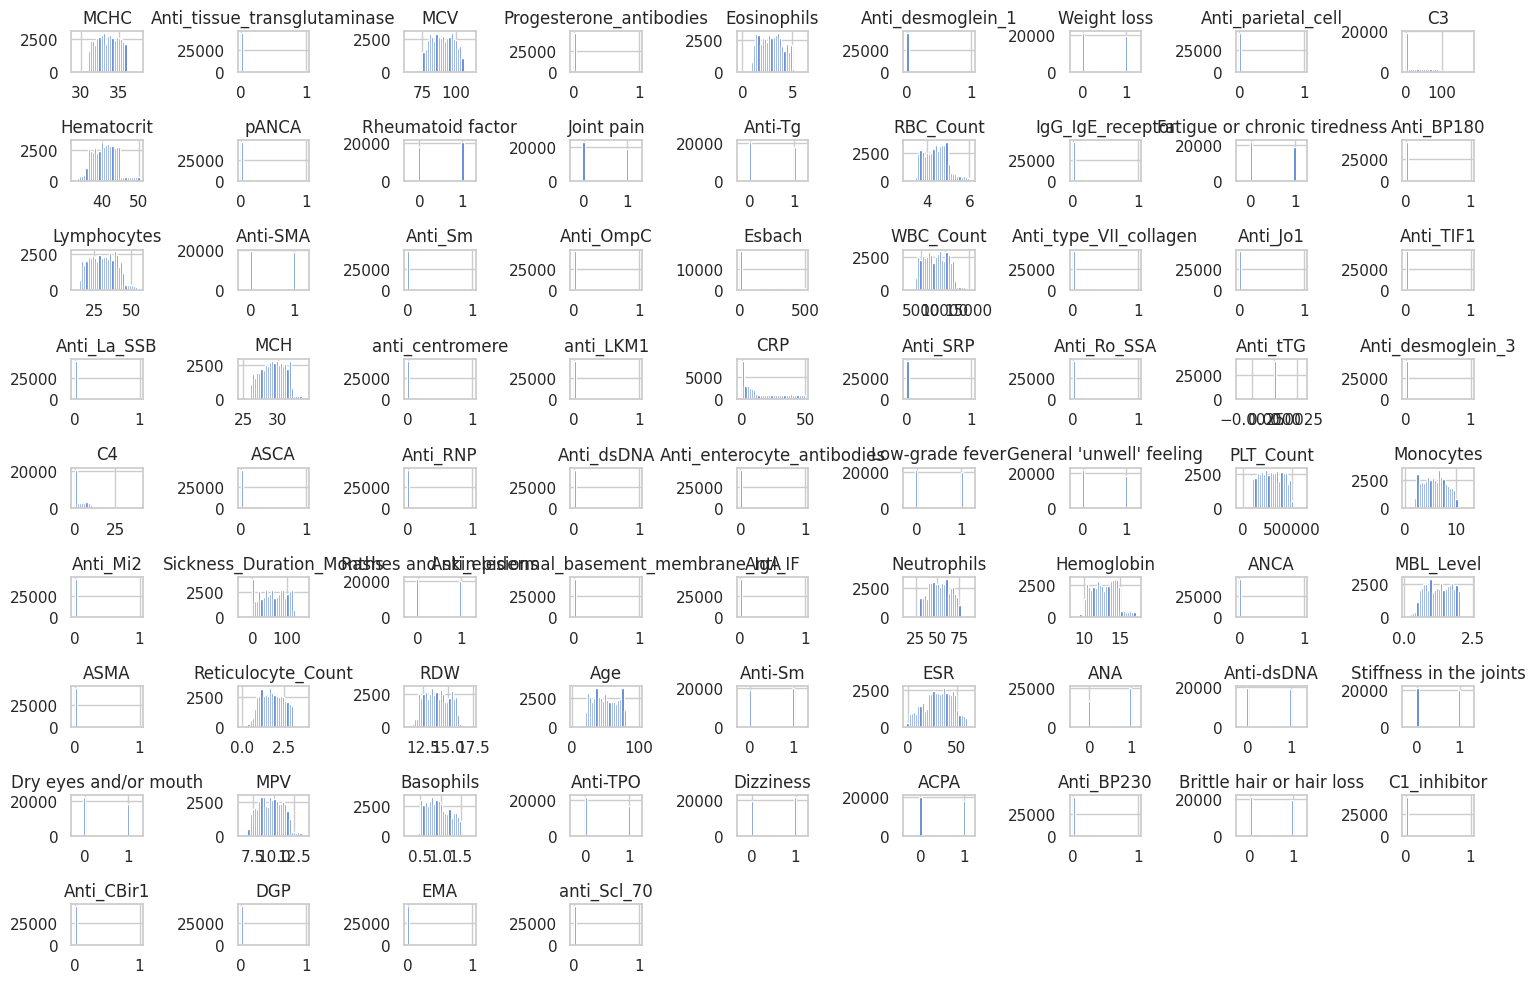

In [65]:
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

### Bivariate Analysis (Features vs. Diseases)

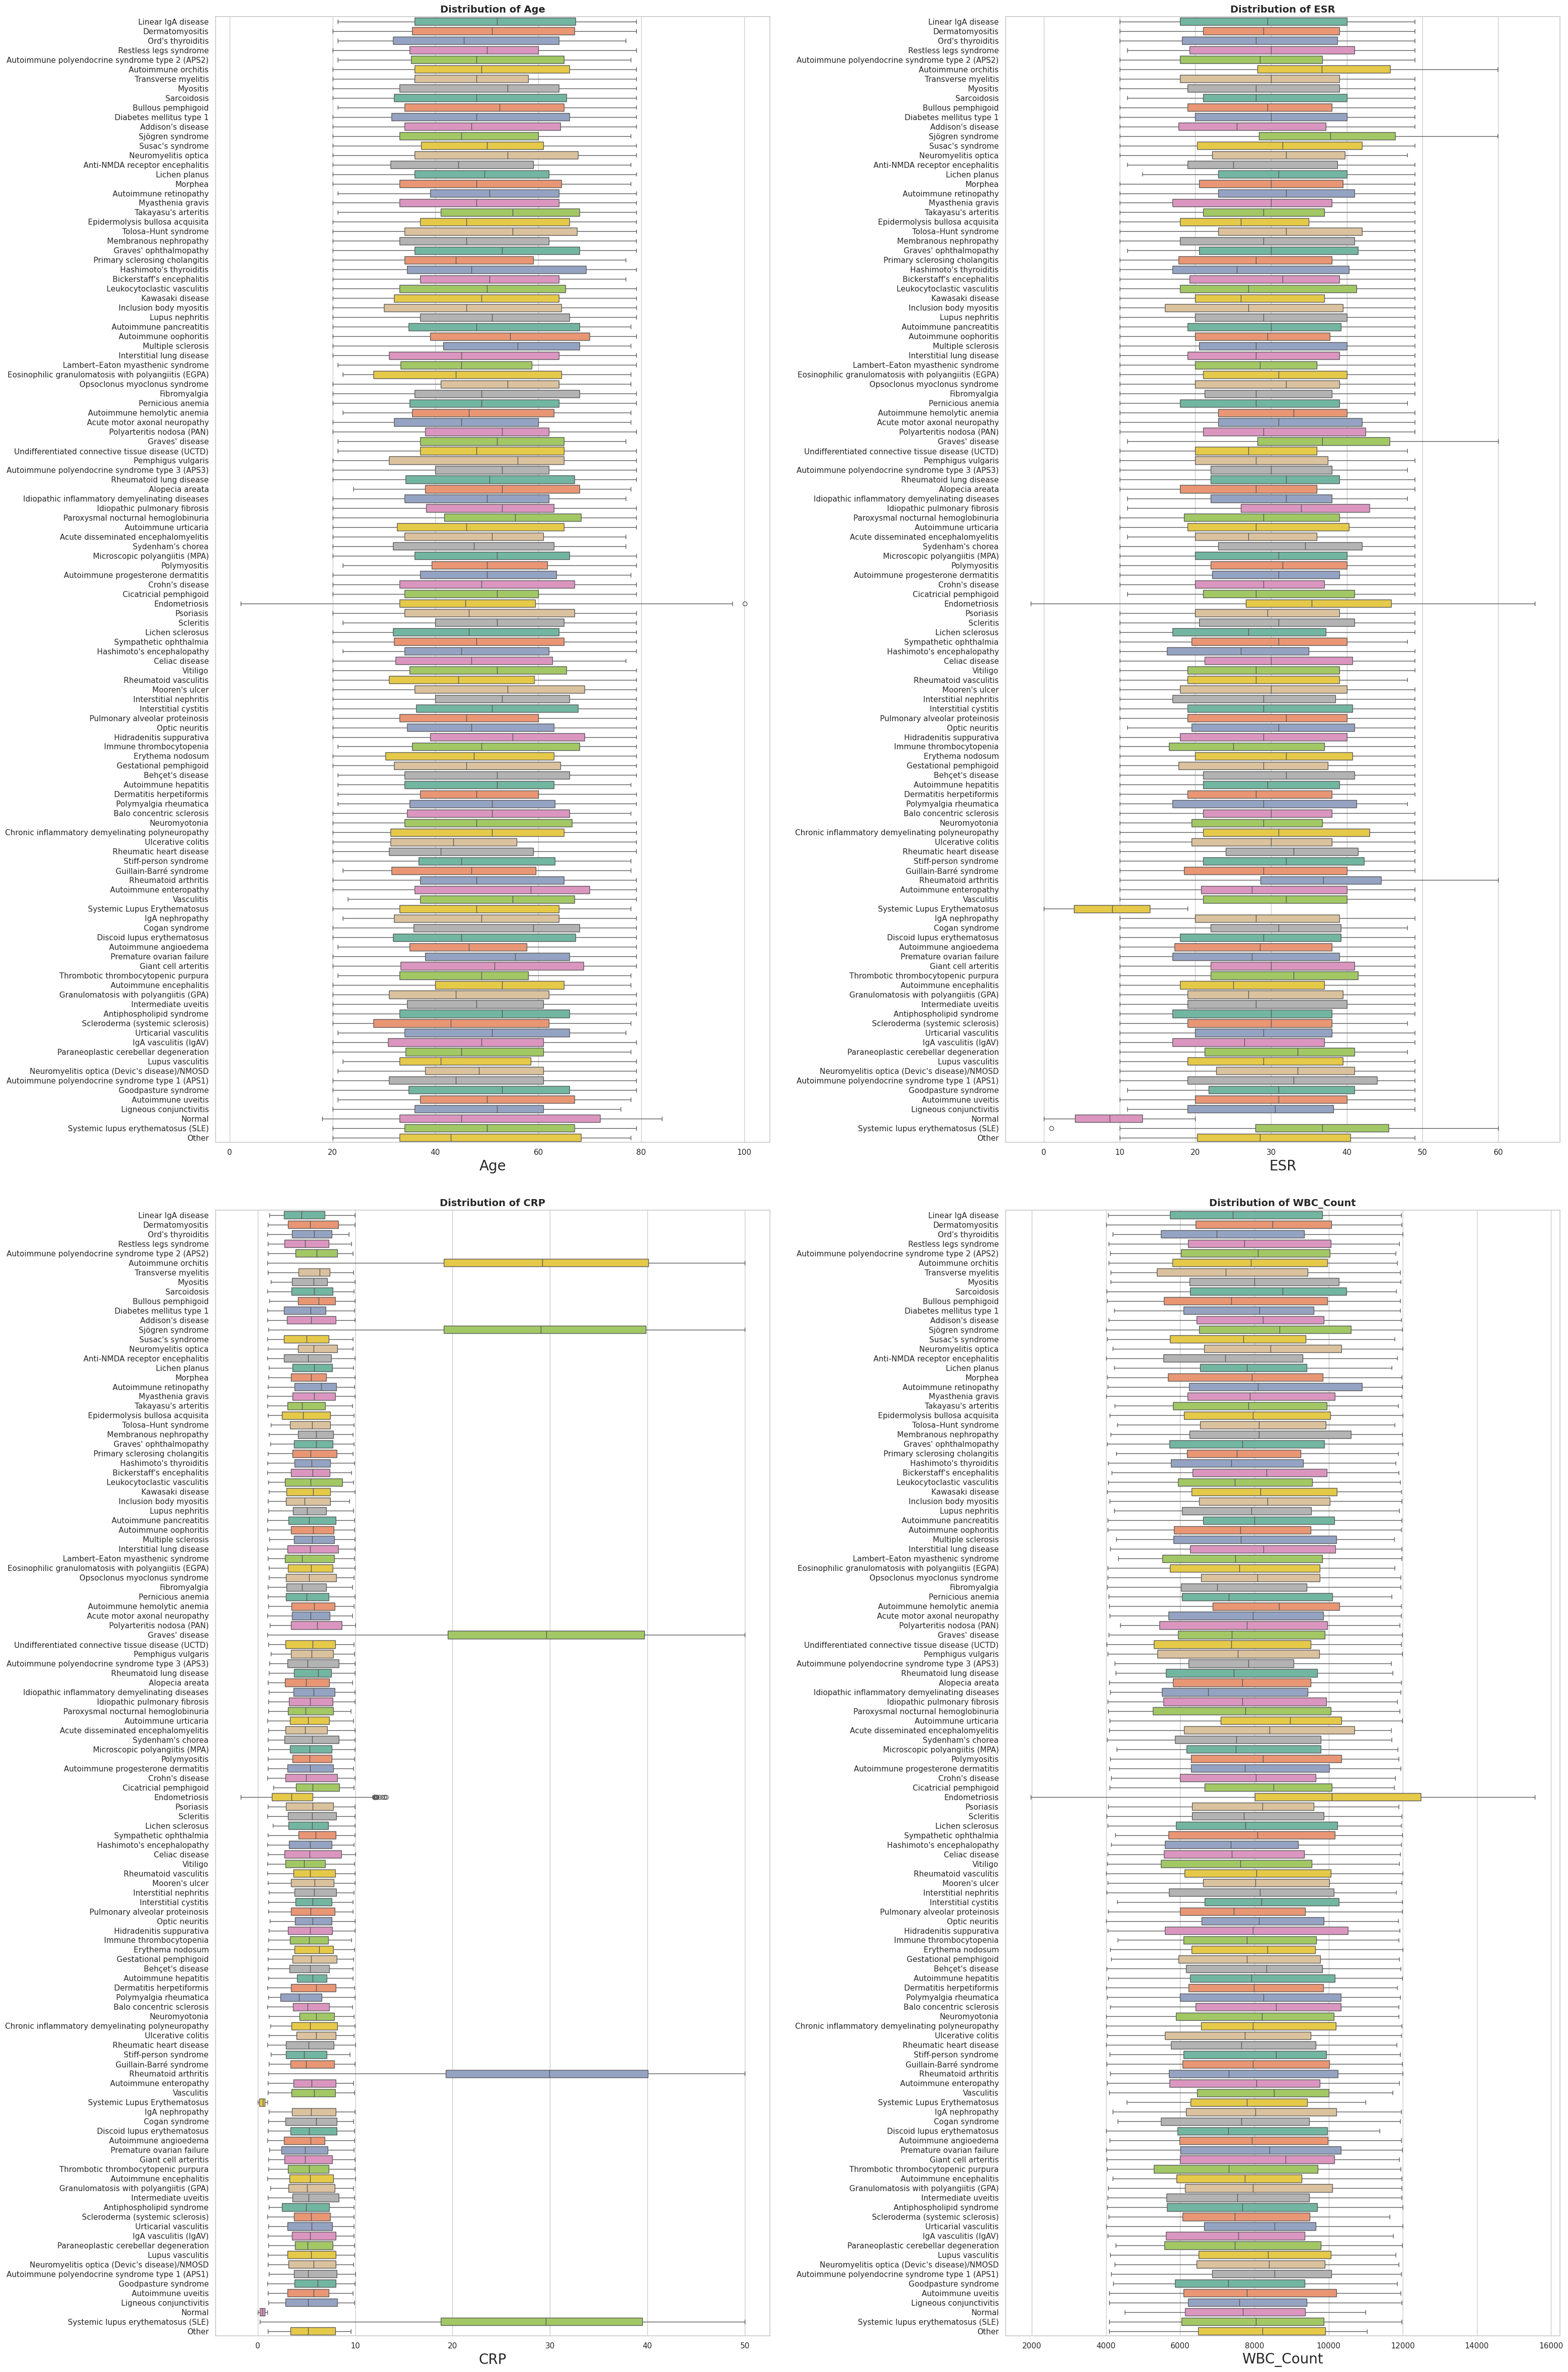

In [66]:
features_to_compare = [f for f in ['Age', 'ESR', 'CRP', 'WBC_Count'] if f in df.columns]

plt.figure(figsize=(32, 48))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=20)

plt.tight_layout(pad=3.0)
plt.show()

### Bivariate Analysis (Features vs. TOP 5 Diseases)

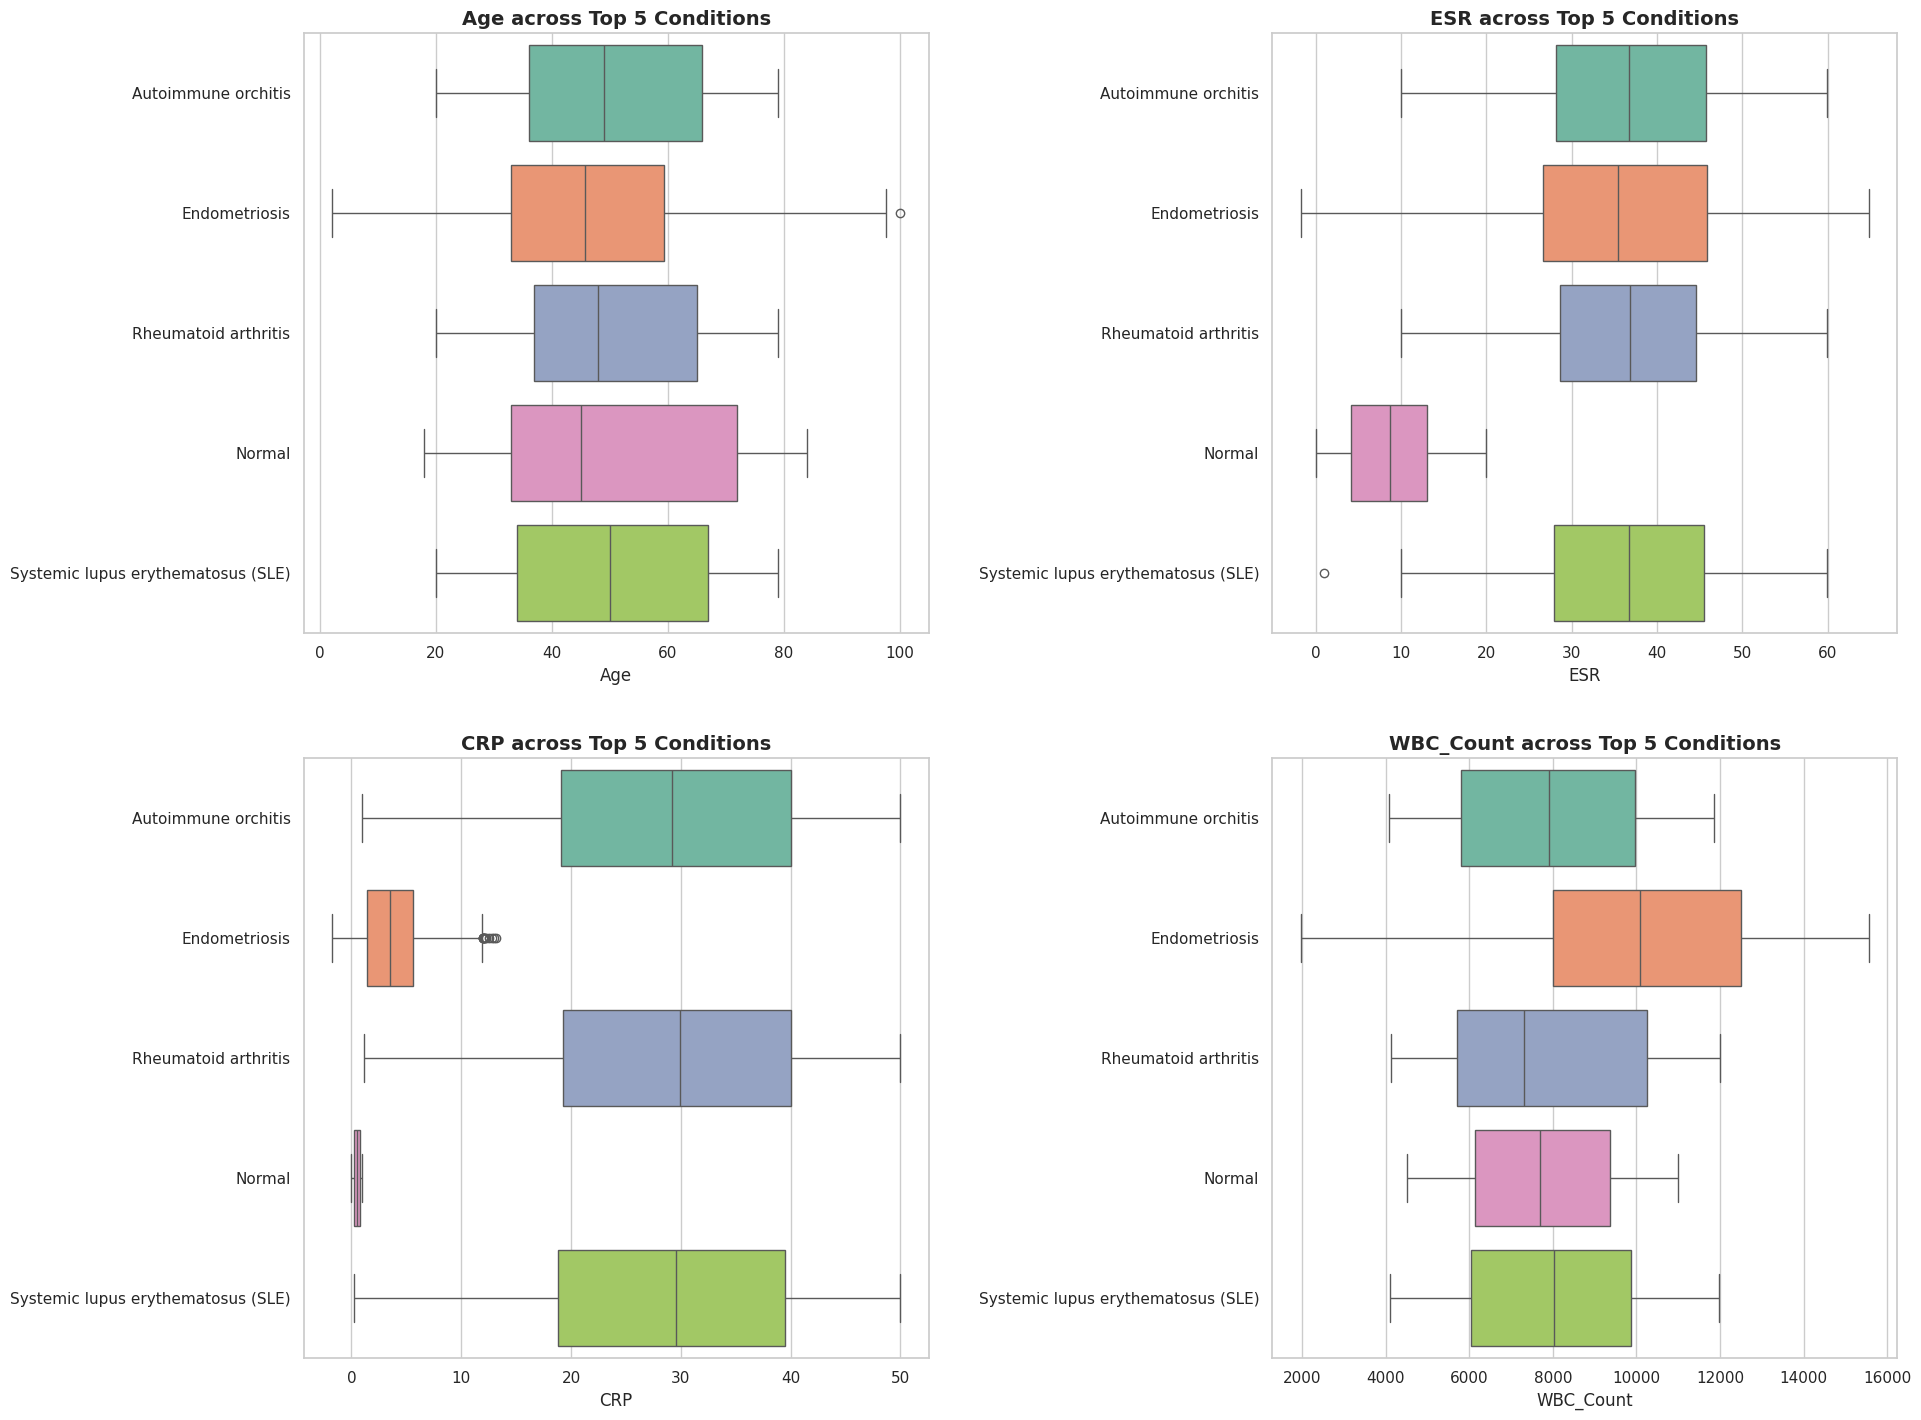

In [67]:
top_5_diseases = df[target_col].value_counts().index[:5]
df_top5 = df[df[target_col].isin(top_5_diseases)]

plt.figure(figsize=(20, 15))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_top5, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)
    plt.title(f'{col} across Top 5 Conditions', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

### Multivariate Analysis (Correlation & Multicollinearity)

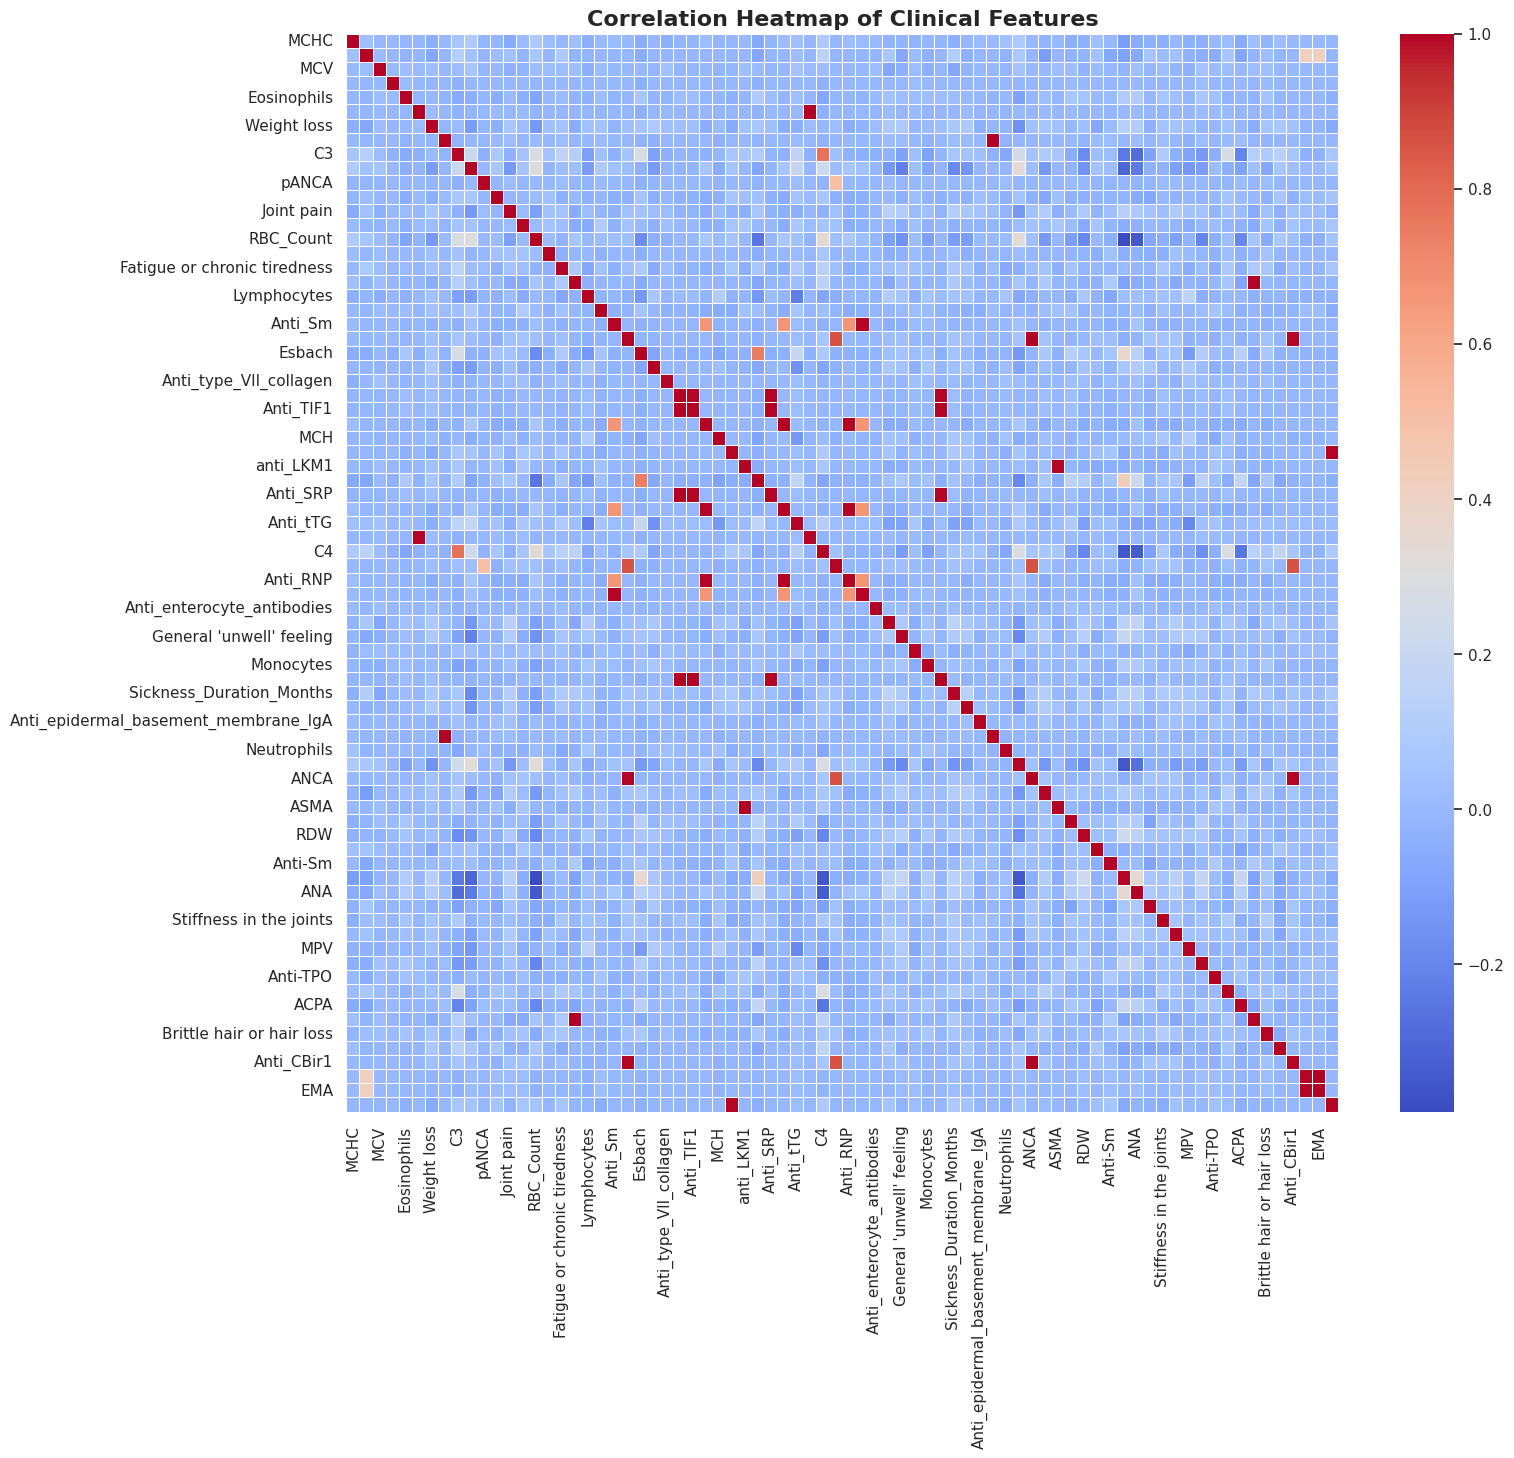

HIGHLY CORRELATED FEATURES (> 0.8)
Consider dropping these columns: ['Anti_TIF1', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_desmoglein_3', 'ASCA', 'Anti_RNP', 'Anti_dsDNA', 'Anti_Mi2', 'Anti_IF', 'ANCA', 'ASMA', 'Anti_BP230', 'Anti_CBir1', 'EMA', 'anti_Scl_70']


In [68]:
plt.figure(figsize=(16, 14))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features', fontsize=16, fontweight='bold')
plt.show()

print("HIGHLY CORRELATED FEATURES (> 0.8)")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(f"Consider dropping these columns: {high_corr}")

### Categorical Analysis (Gender)

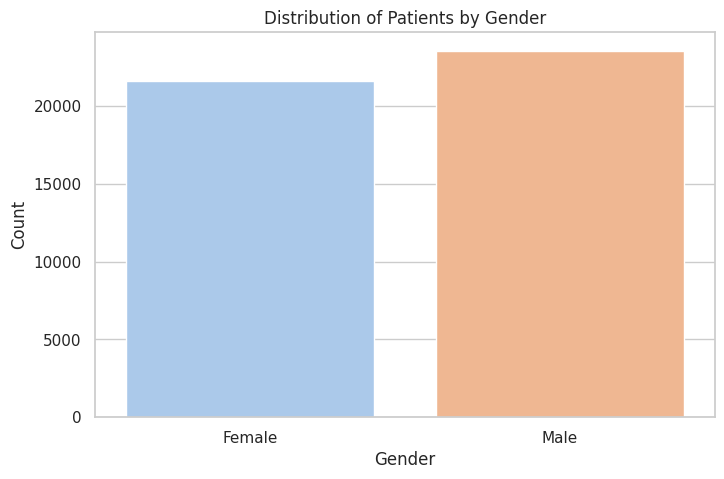

In [69]:
if 'Gender' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Gender', palette='pastel')
    plt.title('Distribution of Patients by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.show()

---
## Section 2: Paper Implementation
### Paper: *Machine Learning Approach for Predicting SLE in an Oman-Based Cohort*
### Oman Medical Journal (Sultan Qaboos University), 2023
**Method:** Binary classification (SLE vs Non-SLE) using RFE feature selection + CatBoost + SHAP interpretability

**Paper results:** AUC = 0.95, Sensitivity = 92%

### Step 1 — Find SLE Label & Create Binary Target

In [70]:
# Standardize all lupus-related labels into one single 'SLE' label
lupus_names = [
    'Systemic lupus erythematosus (SLE)',
    'Systemic Lupus Erythematosus',
    'Lupus nephritis',
    'Lupus vasculitis'
]
df['Diagnosis'] = df['Diagnosis'].replace(lupus_names, 'SLE')

# Create binary target: SLE=1, everything else=0
df['SLE_Target'] = (df['Diagnosis'] == 'SLE').astype(int)

print('Binary target distribution:')
print(df['SLE_Target'].value_counts())
print(f'\nSLE prevalence: {df["SLE_Target"].mean()*100:.1f}%')

Binary target distribution:
SLE_Target
0    39934
1     5271
Name: count, dtype: int64

SLE prevalence: 11.7%


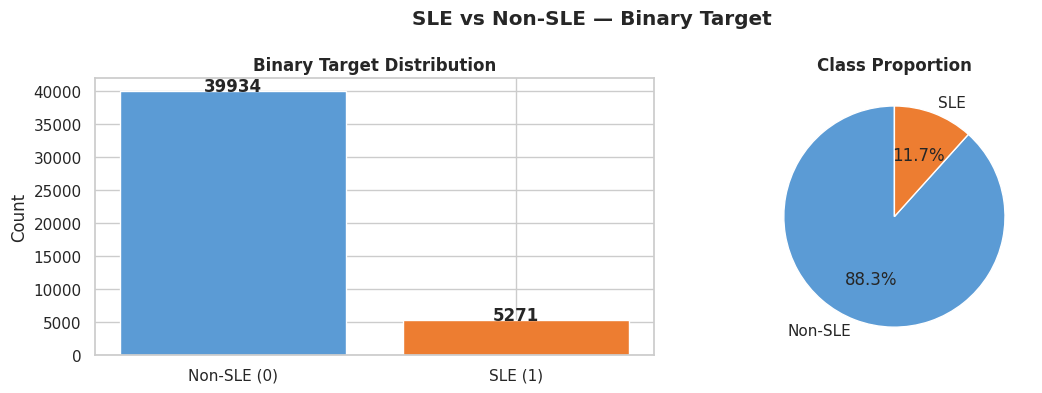

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['SLE_Target'].value_counts()
axes[0].bar(['Non-SLE (0)', 'SLE (1)'], counts.values, color=['#5B9BD5', '#ED7D31'])
axes[0].set_title('Binary Target Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Non-SLE', 'SLE'], autopct='%1.1f%%',
            colors=['#5B9BD5', '#ED7D31'], startangle=90)
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('SLE vs Non-SLE — Binary Target', fontweight='bold')
plt.tight_layout()
plt.show()

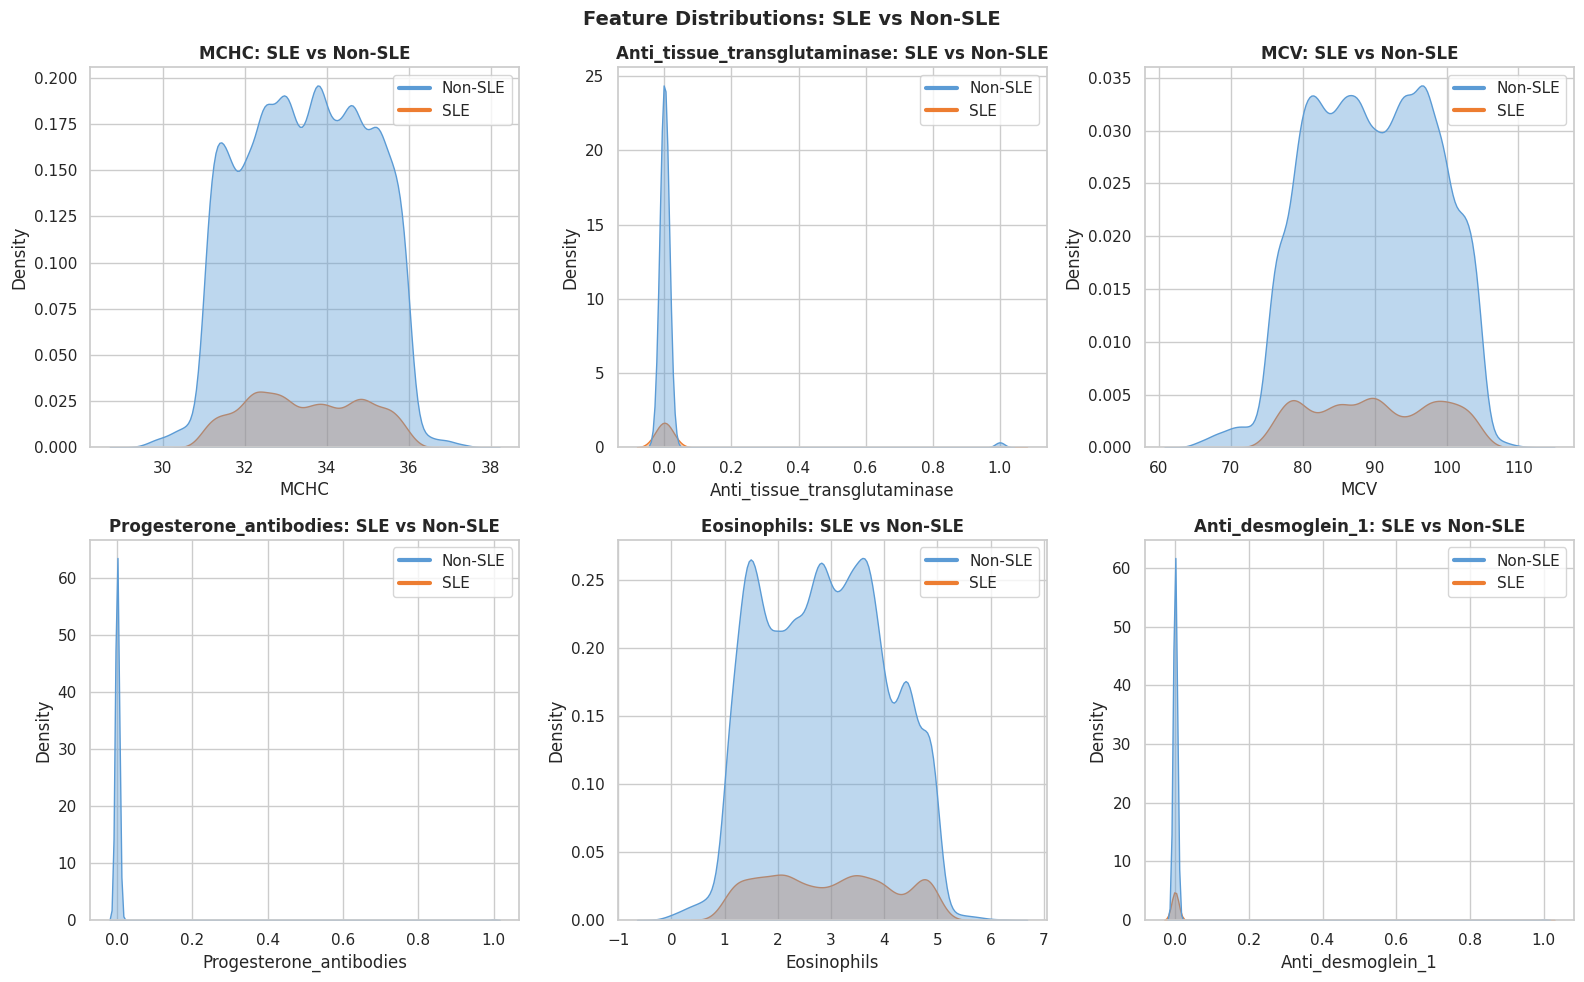

In [72]:
num_features = [c for c in df.select_dtypes(include=['float64','int64']).columns
                if c not in ['SLE_Target', 'Patient_ID']]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features[:6]):
    sns.kdeplot(data=df, x=feat, hue='SLE_Target', ax=axes[i],
                palette={0: '#5B9BD5', 1: '#ED7D31'}, fill=True, alpha=0.4)
    axes[i].set_title(f'{feat}: SLE vs Non-SLE', fontweight='bold')
    handles = [plt.Line2D([0],[0], color='#5B9BD5', lw=3),
               plt.Line2D([0],[0], color='#ED7D31', lw=3)]
    axes[i].legend(handles, ['Non-SLE', 'SLE'])

plt.suptitle('Feature Distributions: SLE vs Non-SLE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

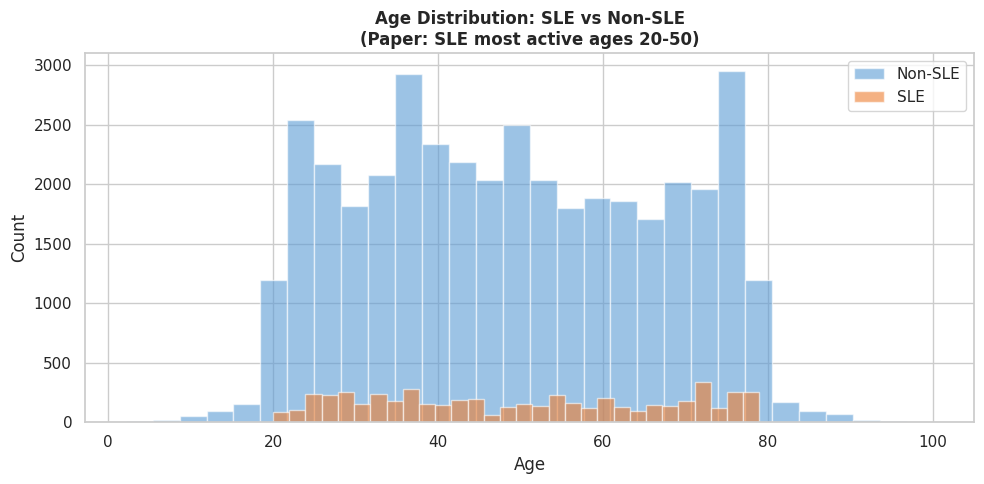

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))
df[df['SLE_Target'] == 0]['Age'].hist(bins=30, alpha=0.6, label='Non-SLE', color='#5B9BD5', ax=ax)
df[df['SLE_Target'] == 1]['Age'].hist(bins=30, alpha=0.6, label='SLE', color='#ED7D31', ax=ax)
ax.set_title('Age Distribution: SLE vs Non-SLE\n(Paper: SLE most active ages 20-50)', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

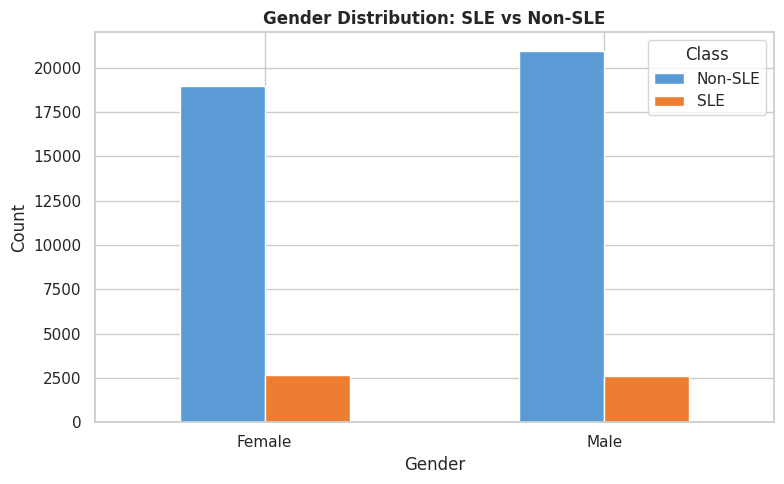

In [74]:
if 'Gender' in df.columns:
    sle_gender = df.groupby(['Gender', 'SLE_Target']).size().unstack(fill_value=0)
    sle_gender.columns = ['Non-SLE', 'SLE']
    sle_gender.plot(kind='bar', figsize=(8, 5), color=['#5B9BD5', '#ED7D31'], edgecolor='white')
    plt.title('Gender Distribution: SLE vs Non-SLE', fontweight='bold')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

In [75]:
df_model = df.copy()
df_model.drop(columns=['Patient_ID', 'Research_Target'], errors='ignore', inplace=True)

for col in df_model.select_dtypes(include='number').columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

cat_cols = [c for c in df_model.select_dtypes(include='object').columns
            if c != 'Diagnosis']
le_enc = LabelEncoder()
for col in cat_cols:
    df_model[col] = le_enc.fit_transform(df_model[col].astype(str))

print(f"Missing values remaining: {df_model.isnull().sum().sum()}")
print(f"Shape: {df_model.shape}")

Missing values remaining: 0
Shape: (45205, 79)


In [76]:
X = df_model.drop(columns=['Diagnosis', 'SLE_Target', 'Research_Target'], errors='ignore')
y = df_model['SLE_Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | SLE rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}  | SLE rate: {y_test.mean():.2%}")
print(f"Columns in X: {X.columns.tolist()}")

Train: (36164, 77) | SLE rate: 11.66%
Test:  (9041, 77)  | SLE rate: 11.66%
Columns in X: ['MCHC', 'Anti_tissue_transglutaminase', 'MCV', 'Progesterone_antibodies', 'Eosinophils', 'Anti_desmoglein_1', 'Weight loss', 'Anti_parietal_cell', 'C3', 'Hematocrit', 'pANCA', 'Rheumatoid factor', 'Joint pain', 'Anti-Tg', 'RBC_Count', 'IgG_IgE_receptor', 'Fatigue or chronic tiredness', 'Anti_BP180', 'Lymphocytes', 'Anti-SMA', 'Anti_Sm', 'Anti_OmpC', 'Esbach', 'WBC_Count', 'Anti_type_VII_collagen', 'Anti_Jo1', 'Anti_TIF1', 'Anti_La_SSB', 'MCH', 'anti_centromere', 'anti_LKM1', 'CRP', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_tTG', 'Anti_desmoglein_3', 'C4', 'ASCA', 'Anti_RNP', 'Anti_dsDNA', 'Anti_enterocyte_antibodies', 'Low-grade fever', "General 'unwell' feeling", 'PLT_Count', 'Monocytes', 'Anti_Mi2', 'Sickness_Duration_Months', 'Rashes and skin lesions', 'Anti_epidermal_basement_membrane_IgA', 'Anti_IF', 'Neutrophils', 'Hemoglobin', 'ANCA', 'MBL_Level', 'ASMA', 'Reticulocyte_Count', 'RDW', 'Age', 'Anti-S

In [77]:
n_features_to_select = min(10, X_train.shape[1])

rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    n_features_to_select=n_features_to_select,
    step=1
)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_].tolist()
print(f"Selected {len(selected_features)} features:")
for f in selected_features:
    print(f"  - {f}")

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

Selected 10 features:
  - MCV
  - Eosinophils
  - Hematocrit
  - Lymphocytes
  - Esbach
  - WBC_Count
  - Monocytes
  - Neutrophils
  - Hemoglobin
  - Reticulocyte_Count


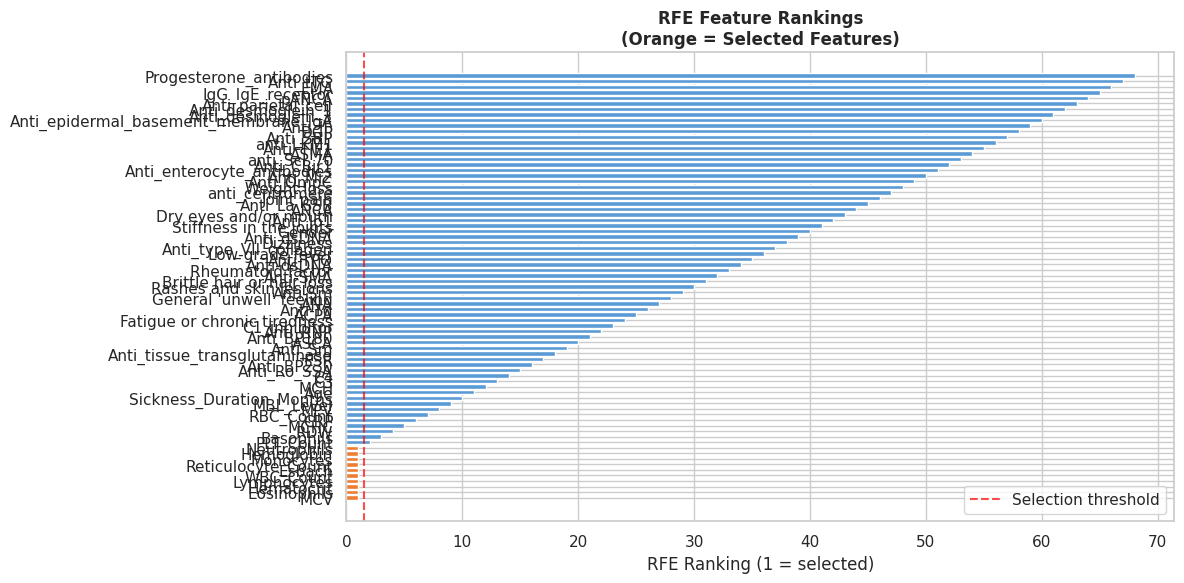

In [78]:
rfe_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

plt.figure(figsize=(12, 6))
bar_colors = ['#ED7D31' if r == 1 else '#5B9BD5' for r in rfe_df['Ranking']]
plt.barh(rfe_df['Feature'], rfe_df['Ranking'], color=bar_colors)
plt.xlabel('RFE Ranking (1 = selected)')
plt.title('RFE Feature Rankings\n(Orange = Selected Features)', fontweight='bold')
plt.axvline(x=1.5, color='red', linestyle='--', alpha=0.7, label='Selection threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print(f"Class weights: {class_weights_dict}")

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    class_weights=[class_weights_dict[0], class_weights_dict[1]]
)

catboost_model.fit(
    X_train_sel, y_train,
    eval_set=(X_test_sel, y_test),
    plot=False
)
print('Training complete.')

Class weights: {np.int64(0): np.float64(0.5659999373963126), np.int64(1): np.float64(4.287882380839459)}
0:	test: 0.7941318	best: 0.7941318 (0)	total: 45ms	remaining: 22.5s
100:	test: 0.9587638	best: 0.9587638 (100)	total: 1.91s	remaining: 7.53s
200:	test: 0.9767358	best: 0.9767358 (200)	total: 5.47s	remaining: 8.14s
300:	test: 0.9815333	best: 0.9815333 (300)	total: 9.42s	remaining: 6.23s
400:	test: 0.9834623	best: 0.9835063 (397)	total: 14.7s	remaining: 3.62s
499:	test: 0.9842416	best: 0.9843094 (487)	total: 18.7s	remaining: 0us

bestTest = 0.9843094174
bestIteration = 487

Shrink model to first 488 iterations.
Training complete.


In [80]:
y_prob_full = catboost_model.predict_proba(X_test_sel)
y_prob = y_prob_full[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

acc       = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print(f'Threshold used: {threshold}')
print('=' * 50)
print(f'  Accuracy : {acc:.4f}')
print(f'  AUC      : {auc_score:.4f}  (Paper: 0.95)')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Non-SLE', 'SLE']))
print(f'SLE predictions: {y_pred.sum()} out of {len(y_pred)}')

Threshold used: 0.3
  Accuracy : 0.9646
  AUC      : 0.9843  (Paper: 0.95)
              precision    recall  f1-score   support

     Non-SLE       0.99      0.97      0.98      7987
         SLE       0.78      0.96      0.86      1054

    accuracy                           0.96      9041
   macro avg       0.89      0.96      0.92      9041
weighted avg       0.97      0.96      0.97      9041

SLE predictions: 1292 out of 9041


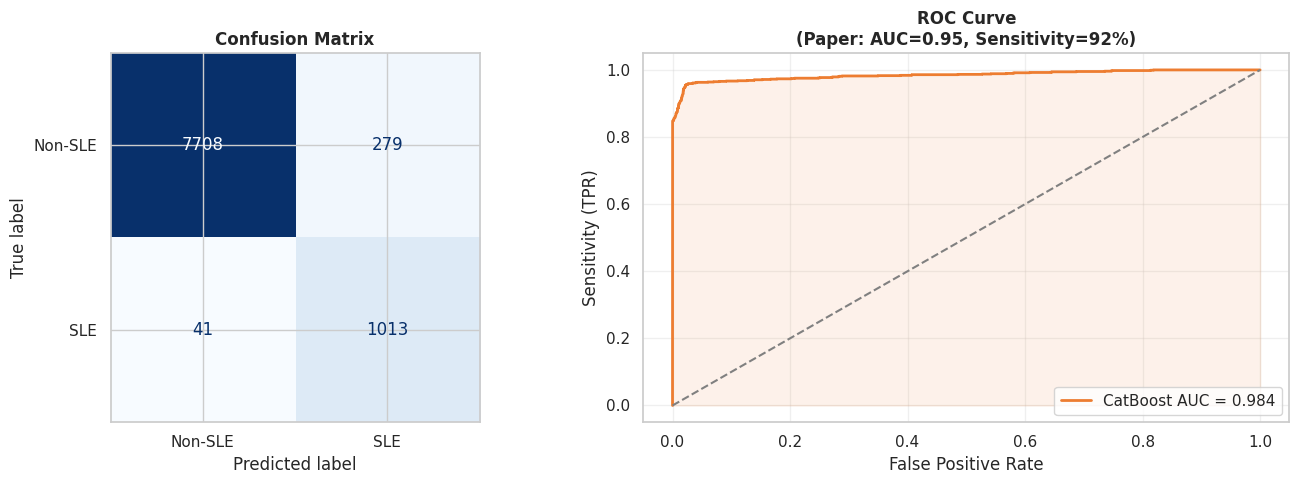

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-SLE', 'SLE']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#ED7D31', lw=2, label=f'CatBoost AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'gray', linestyle='--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#ED7D31')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('Sensitivity (TPR)')
axes[1].set_title('ROC Curve\n(Paper: AUC=0.95, Sensitivity=92%)', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
cv_model = CatBoostClassifier(
    iterations=300, learning_rate=0.05,
    depth=6, random_seed=42, verbose=0
)
cv_scores = cross_val_score(
    cv_model, X[selected_features], y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'5-Fold CV AUC : {cv_scores.round(4)}')
print(f'Mean +/- Std  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-Fold CV AUC : [0.9685 0.9641 0.9672 0.9725 0.9662]
Mean +/- Std  : 0.9677 +/- 0.0028


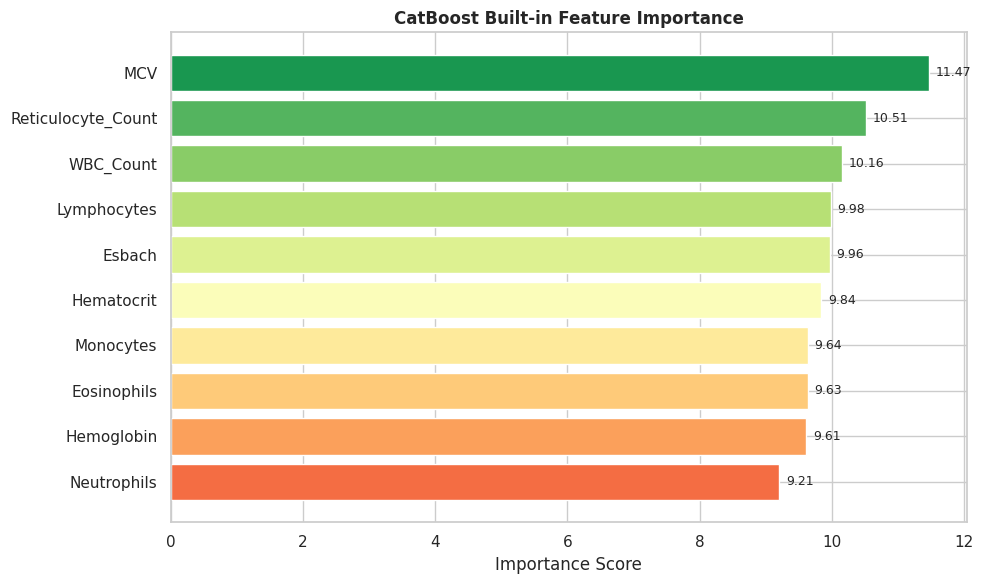

In [83]:
feat_imp = pd.Series(
    catboost_model.get_feature_importance(),
    index=selected_features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
imp_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
bars = plt.barh(feat_imp.index, feat_imp.values, color=imp_colors, edgecolor='white')
plt.xlabel('Importance Score')
plt.title('CatBoost Built-in Feature Importance', fontweight='bold')
for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [84]:
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test_sel)
print(f'SHAP values shape: {np.array(shap_values).shape}')
print('SHAP values computed.')

SHAP values shape: (9041, 10)
SHAP values computed.


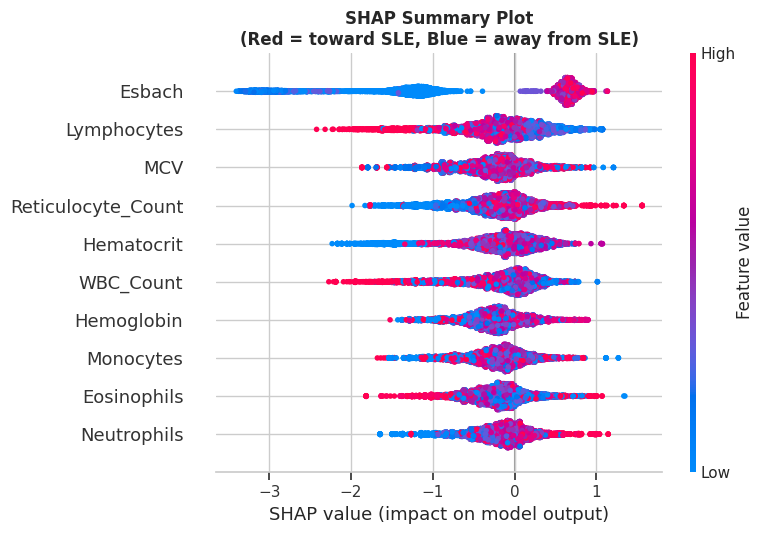

In [85]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type='dot', show=False)
plt.title('SHAP Summary Plot\n(Red = toward SLE, Blue = away from SLE)', fontweight='bold')
plt.tight_layout()
plt.show()

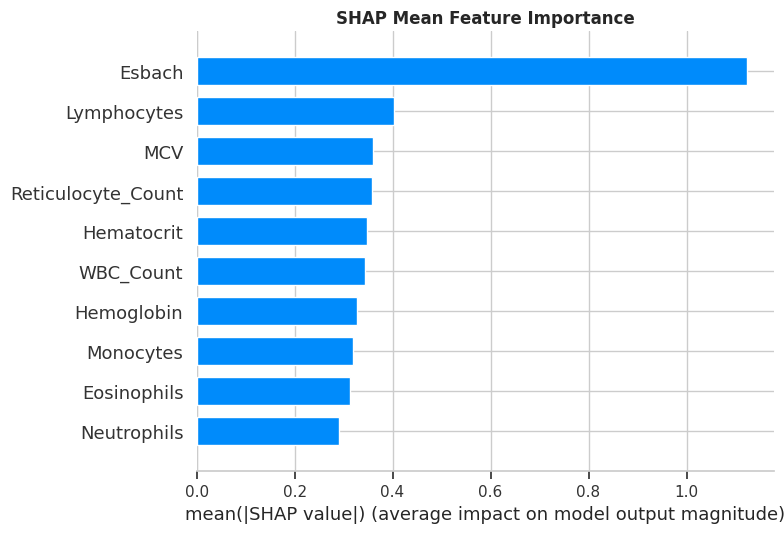

In [86]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type='bar', show=False)
plt.title('SHAP Mean Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

Patient #6 | SLE prob: 0.9369 | Actual: 1


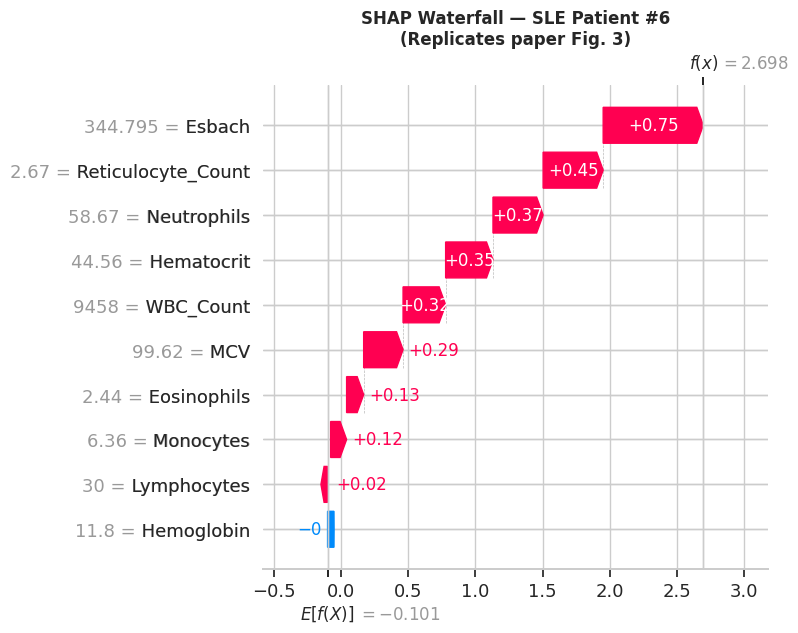

In [87]:
sle_indices = np.where((np.array(y_pred) == 1) & (y_test.values == 1))[0]

if len(sle_indices) == 0:
    print("No true positives found — using highest SLE probability patient")
    patient_idx = int(np.argmax(y_prob))
else:
    patient_idx = sle_indices[0]

print(f'Patient #{patient_idx} | SLE prob: {y_prob[patient_idx]:.4f} | Actual: {y_test.values[patient_idx]}')

explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_test_sel.iloc[patient_idx].values,
    feature_names=selected_features
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP Waterfall — SLE Patient #{patient_idx}\n(Replicates paper Fig. 3)', fontweight='bold')
plt.tight_layout()
plt.show()

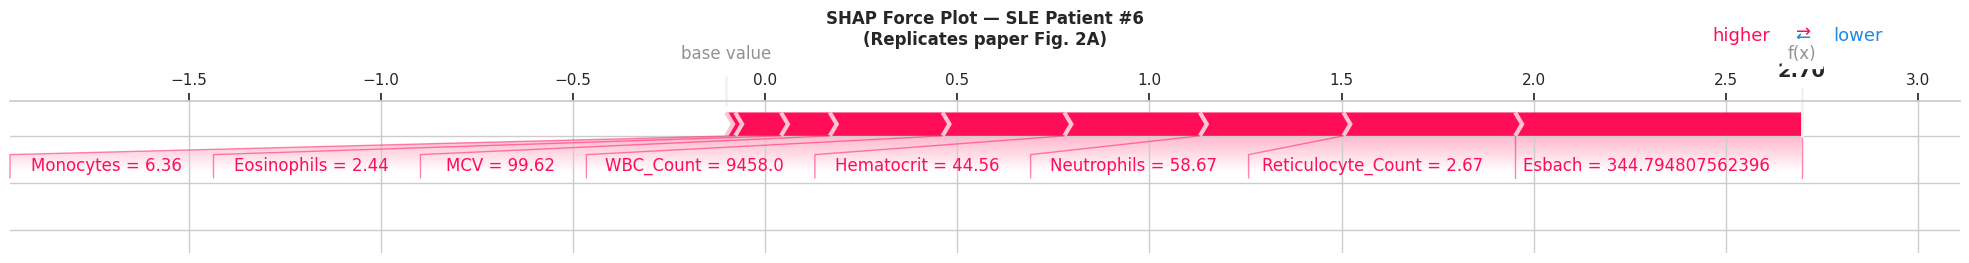

In [88]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[patient_idx],
    X_test_sel.iloc[patient_idx],
    feature_names=selected_features,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — SLE Patient #{patient_idx}\n(Replicates paper Fig. 2A)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Patient #0 | SLE prob: 0.0072 | Actual: 0


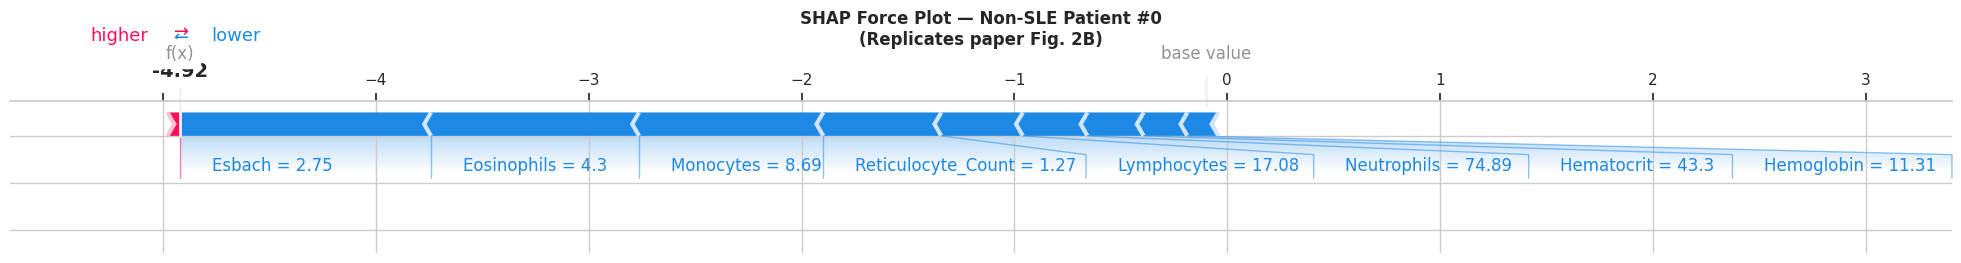

In [89]:
non_sle_indices = np.where((np.array(y_pred) == 0) & (y_test.values == 0))[0]
p2_idx = non_sle_indices[0] if len(non_sle_indices) > 0 else int(np.argmin(y_prob))

print(f'Patient #{p2_idx} | SLE prob: {y_prob[p2_idx]:.4f} | Actual: {y_test.values[p2_idx]}')

shap.force_plot(
    explainer.expected_value,
    shap_values[p2_idx],
    X_test_sel.iloc[p2_idx],
    feature_names=selected_features,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Non-SLE Patient #{p2_idx}\n(Replicates paper Fig. 2B)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [90]:
sensitivity = recall_score(y_test, y_pred, pos_label=1)
specificity = recall_score(y_test, y_pred, pos_label=0)
precision   = precision_score(y_test, y_pred, pos_label=1)
f1          = f1_score(y_test, y_pred, pos_label=1)

print('=' * 55)
print('     AHMED ABDELSALAM — CATBOOST RESULTS SUMMARY')
print('=' * 55)
print(f'  Accuracy    : {acc:.4f}')
print(f'  AUC (ROC)   : {auc_score:.4f}   | Paper target: 0.95')
print(f'  Sensitivity : {sensitivity:.4f}   | Paper target: 0.92')
print(f'  Specificity : {specificity:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'  F1 Score    : {f1:.4f}')
print(f'  Threshold   : {threshold}')
print(f'  CV AUC      : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print('=' * 55)
print(f'  RFE selected features ({len(selected_features)}):')
for f in selected_features:
    print(f'    - {f}')
print('=' * 55)

     AHMED ABDELSALAM — CATBOOST RESULTS SUMMARY
  Accuracy    : 0.9646
  AUC (ROC)   : 0.9843   | Paper target: 0.95
  Sensitivity : 0.9611   | Paper target: 0.92
  Specificity : 0.9651
  Precision   : 0.7841
  F1 Score    : 0.8636
  Threshold   : 0.3
  CV AUC      : 0.9677 +/- 0.0028
  RFE selected features (10):
    - MCV
    - Eosinophils
    - Hematocrit
    - Lymphocytes
    - Esbach
    - WBC_Count
    - Monocytes
    - Neutrophils
    - Hemoglobin
    - Reticulocyte_Count
